<center><h1><strong>Motherhood Meets AI</h1>
Kamri Williams

<h2>1. Introduction:</h2>

-------------------------
<h3><strong>Project Overview</h3>

This project analyzes real survey feedback from moms about how they use (or avoid) AI in their daily lives. The goal is to turn raw responses into clear insights about behavior, needs, and attitudes. Using clustering, the project identifies distinct personas that represent the major types of AI users within the mom community.

<h3>G<strong>oal / Problem Statement</h3>

Moms juggle many roles, yet very little research explores how they actually use AI or what support they need. 
<br>This project aims to answer three questions:
- How are moms using AI today?
- What motivates or prevents adoption?
- an we group moms into meaningful user personas?

<h3><strong>Dataset Description</h3>

The dataset includes survey responses from moms describing their AI habits, use cases, concerns, and comfort levels. Many responses contain multiple behaviors, so the data was cleaned, split, and encoded to make it suitable for clustering analysis.

<h3><strong>What the Analysis Produces (Personas)</h3>

The analysis generates several personas — each representing a unique pattern of AI behavior, mindset, and needs. These personas help explain:

- Who uses AI heavily
- Who is cautious or selective
- Who avoids AI completely
- What each group needs for better support or adoption


<h2>2. Import Libraries</h2>

-------------------------

In [23]:
import pandas as pd
import matplotlib
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns

<h2>3. Load & Preview Data</h2>

-------------------------

In [6]:
# Load the survey data and get a quick overview of its structure
df = pd.read_csv("moms_ai_survey.csv")
df.head()
df.info(5)

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             52 non-null     str  
 1   mom_type         52 non-null     str  
 2   uses_ai          52 non-null     str  
 3   how_use_ai       52 non-null     str  
 4   tools_mentioned  42 non-null     str  
 5   attitude         52 non-null     str  
dtypes: str(6)
memory usage: 2.6 KB


In [7]:
## Inspect column names to understand what information is available in the dataset

# Vieewing columns
df.columns

# View Shape
df.shape


(52, 6)

In [8]:
# Check the distribution of key fields like AI usage and attitude toward AI

df['uses_ai'].value_counts() 
df['attitude'].value_counts()



attitude
positive         26
mixed            11
negative          6
very positive     5
neutral           4
Name: count, dtype: int64

<h2>4. Data Cleaning</h2>

-------------------------
This dataset required minimal cleaning. Most survey responses were already structured, so only light preprocessing was needed. Multi-response text fields were split and encoded for modeling, and simple transformations (like converting yes/no to 1/0) prepared the data for clustering. No extensive handling of missing values or outliers was required.

In [9]:
# Converting Yes/No values into binary form so we can use it later 
df["uses_ai"] = df["uses_ai"].str.lower().map({"yes": 1, "no": 0})
df["uses_ai"] 

0     1
1     0
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     0
10    0
11    1
12    1
13    1
14    0
15    1
16    1
17    0
18    1
19    1
20    0
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    0
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    1
43    0
44    1
45    1
46    1
47    0
48    1
49    1
50    0
51    1
Name: uses_ai, dtype: int64

<h2>5. Feature Engineering</h2>

-------------------------
To prepare the data for clustering, several new features were created:

Use-Case Categories:
A custom function classified AI behaviors (e.g., organization, schoolwork, creativity) from open-text responses.

Mom-Type Categories:
Another function grouped employment/lifestyle descriptions into consistent categories (e.g., SAHM, Working Mom, Student Mom).

Multi-Label Encoding:
Multi-response fields were expanded into binary columns using multi-label encoding.

Numeric Features:
Yes/no fields were converted to 1/0 for modeling.

These engineered features transformed qualitative responses into structured data the clustering model could interpret.

In [47]:
# Explore raw AI use-case responses to identify common themes and define category labels
df["how_use_ai"].head(10)

0    Uses ChatGPT for quick answers, scheduling ide...
1    Avoids AI; prefers natural writing and intuition.
2    Uses AI for checking symptoms, homework help, ...
3    Uses Alexa for routines and alarms; uses ChatG...
4    Uses ChatGPT for business brainstorming; likes...
5    Uses AI for planning, research, writing suppor...
6    Uses Gemini daily for tasks and AI tools in Wi...
7    Uses AI for brainstorming, budgeting, lists, a...
8    Uses AI mainly for grammar checks, quick answe...
9    Doesn't use AI at all; busy managing multiple ...
Name: how_use_ai, dtype: str

In [48]:
# Feature engineering: extract AI use-case categories from open-ended responses
# Returns a list of one or more behavior labels for each mom (e.g., organization, schoolwork, creativity)


def classify_use_case_multi(text: str) -> list:
    """
    Multi-label classifier: moms can belong to multiple categories.
    Returns a LIST of categories instead of one.
    """
    t = str(text).lower()
    categories = []

    # 1. Multi-domain power user
    if any(phrase in t for phrase in [
        "everything", "school, work", "work, school", "heavily rely",
        "personal, work", "use ai for school, work"
    ]):
        categories.append("Multi-Domain Power User")

    # 2. Financial planning & credit
    if any(word in t for word in [
        "credit", "dispute", "fix my credit", "budget", "financial plan",
        "expense tracking", "debt", "recovery plan"
    ]):
        categories.append("Financial Planning & Credit Support")

    # 3. Education & study
    if any(word in t for word in [
        "homework", "study", "class", "lesson planning", "apa",
        "flashcards", "math concepts", "explain", "science", "schoolwork", "essays", "break down"
    ]):
        categories.append("Education & Homework Help")

    # 4. Meal planning + routines
    if any(word in t for word in [
        "meal prep", "meal plan", "grocery list", "cleaning routine",
        "chore chart", "sports schedule", "calendars", "household checklist","routine", "routines"
    ]):
        categories.append("Meal Planning, Routines & Mental Load")

    # 5. Parenting & child development
    if any(word in t for word in [
        "toddler", "sensory", "behavior", "calm-down", "bedtime stories",
        "nap routine", "age-specific"
    ]):
        categories.append("Parenting Support & Child Development")

    # 6. Business & work support
    if any(word in t for word in [
        "branding", "client", "inventory", "projections", "proposals",
        "presentation", "wix", "admin", "for business", "slide deck", "content"
    ]):
        categories.append("Business & Professional Support")

    # 7. Writing + organization
    if any(word in t for word in [
        "rewrite emails", "time blocking", "lists", "journaling",
        "grammar", "notes", "summaries", "ideas", "brainstorming"
    ]):
        categories.append("Productivity, Writing & Organization")

    # 8. Health & postpartum
    if any(word in t for word in [
        "symptoms", "health", "postpartum", "feeding schedule",
        "newborn routine"
    ]):
        categories.append("Health & Postpartum Support")

    # 9. Event planning
    if any(word in t for word in [
        "birthday", "holiday", "baby shower", "registries", "events",
        "gift budget"
    ]):
        categories.append("Event Planning & Life Organization")

    # 10. Creative & decor
    if any(word in t for word in [
        "decorating", "decor", "layouts", "invitations", "graphics",
        "ai-generated art"
    ]):
        categories.append("Creative & Home Styling Support")

    # 11. Travel
    if any(word in t for word in [
        "trip", "travel", "outings", "plan trips"
    ]):
        categories.append("Travel & Outing Planning")

    # 12. Emotional support
    if any(word in t for word in [
        "emotional support", "vent", "self-reflection", "journaling"
    ]):
        categories.append("Emotional Support & Reflection")

    # 13. Trust Concerns
    if any(word in text for word in [
        "distrust", "trust issue", "don’t trust", "cant trust", "doesn't trust", "cautious", "authenticity", "privacy", "data privacy",
    ]):
        categories.append("Trust Concerns")

    # 14. Ethical / Environmental Concerns
    if any(word in text for word in [
        "environment", "ethical", "stealing art", "harm", "ethic", "impact on jobs"
    ]):
        categories.append("Ethical/Environmental Concerns")

    # 15. Overwhelmed / Low Tech Confidence
    if any(word in text for word in [
        "overwhelmed", "don’t know where to start", "confusing", "not tech savvy", "unsure", "fears","fear"
    ]):
        categories.append("Overwhelmed / Low Tech Confidence")

    # 16. Doesn’t Trust AI With Parenting
    if any(word in text for word in [
        "don’t trust with parenting", "prefer real moms", "not for parenting", "Doesn't trust AI"
    ]):
        categories.append("Doesn’t Trust AI With Parenting")

    # 17. No AI Use (Neutral)
    if any(word in text for word in [
        "don’t use ai", "no ai","doesn't use ai", "doesnt use ai", "dislikes AI", "Doesn't use AI at all"
    ]):
        categories.append("No AI Use")
        
    # 18. Hasn't Tried (Neutral)
    if any(word in text for word in [
        "hasn't tried", "hasnt tried", "never used"
    ]):
        categories.append("Hasn't Tried")

    # 19. Avoidance 
    if any(phrase in t for phrase in [
        "avoid ai", "avoid", "avoids"
    ]):
        categories.append("Avoids")

    if len(categories) == 0:
        categories.append("Other / Unclear")


    return categories


In [49]:
# Apply multi-label use case classifier
df["use_case_category"] = df["how_use_ai"].apply(classify_use_case_multi)

# Preview results
print("Use Case Categories — Preview")
print(df["use_case_category"].head(5))

# Identify responses that couldn't be classified — ideally this should be empty
unclear = df[df["use_case_category"].apply(lambda x: "Other / Unclear" in x)]
print(f"\nUnclassified responses: {len(unclear)}")
print(unclear[["how_use_ai", "use_case_category"]])

Use Case Categories — Preview
0               [Productivity, Writing & Organization]
1                                             [Avoids]
2    [Education & Homework Help, Health & Postpartu...
3    [Education & Homework Help, Meal Planning, Rou...
4    [Business & Professional Support, Productivity...
Name: use_case_category, dtype: object

Unclassified responses: 0
Empty DataFrame
Columns: [how_use_ai, use_case_category]
Index: []


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=30, stop_words='english')

# You need to handle NaN values first — how_use_ai has some empty responses
text_data = df["how_use_ai"].fillna("Not provided")

tfidf_matrix = vectorizer.fit_transform(text_data)

print("Matrix shape:", tfidf_matrix.shape)
print("Top words found:", vectorizer.get_feature_names_out())

Matrix shape: (52, 30)
Top words found: ['ai' 'avoids' 'budgeting' 'chatgpt' 'create' 'doesn' 'emails' 'feels'
 'generate' 'help' 'homework' 'household' 'ideas' 'lists' 'meal'
 'organize' 'plan' 'planning' 'prep' 'privacy' 'quick' 'routines'
 'schedules' 'simplifying' 'strategies' 'tasks' 'use' 'uses' 'weekly'
 'work']


TF-IDF produces a decimal score that captures both how often a word appears in a response and how rare it is across all responses. It's more reliable because it removes the manual work of deciding which words matter — the math surfaces distinctive language automatically.

My keyword classifier produces a binary 0 or 1 score that determines whether a word appears or not.TF-IDF features are used alongside the rule-based keyword categories rather than replacing them. The keyword categories provide interpretable labels for persona assignment, while TF-IDF captures linguistic patterns that keyword matching alone may miss.

The top 30 words surfaced by TF-IDF closely mirror the use-case categories identified through manual keyword classification — including terms related to meal planning, homework support, budgeting, and privacy concerns. This alignment suggests the rule-based persona framework captures real linguistic patterns in the data rather than reflecting researcher bias."

<h3>Use Case Catergories</h3> 

A) For moms who DO use AI

1. Multi-Domain Power User
2. Financial Planning & Credit Support
3. Education & Homework Help
4. Meal Planning, Routines & Mental Load
5. Parenting Support & Child Development
6. Business & Professional Support
7. Productivity, Writing & Organization
8. Health & Postpartum Support
9. Event Planning & Life Organization
10. Creative & Home Styling Support
11. Travel & Outing Planning
12. Emotional Support & Reflection
    
B) For moms who DO NOT use AI)

13. Trust Concerns
14. Ethical/Environmental Concerns
15. Overwhelmed / Low Tech Confidence
16. Doesn’t Trust AI With Parenting
17. No AI Use
18. Avoids
19. Other


<Axes: xlabel='use_case_category'>

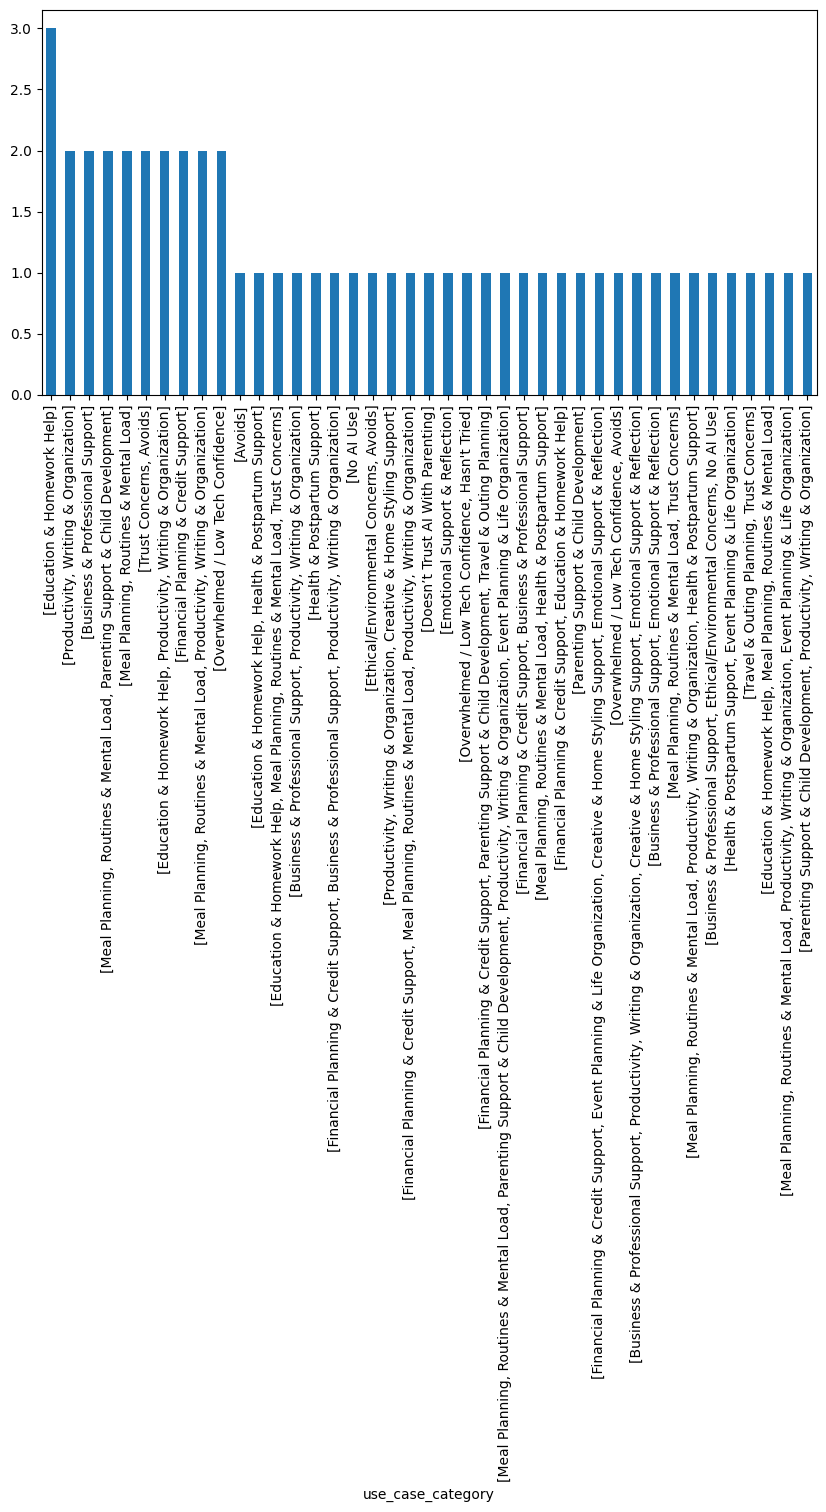

In [51]:
# Inspect the new use_case_category feature to confirm the labels look reasonable
df['use_case_category'].value_counts().plot(kind='bar',figsize=(10,5))

In [52]:
# Feature engineering: normalize raw mom_type text into consistent categories
# Maps each response into buckets like SAHM, Working Mom, Student Mom, WFH Mom, etc.
def normalize_mom_type(text):
    t = text.lower()

    # Stay-at-home moms
    if "sahm" in t or "stay-at-home" in t:
        return "SAHM"

    # Working moms (any variation)
    if "working" in t or "worker" in t or "remote" in t:
        return "Working Mom"

    # Student moms
    if "student" in t:
        return "Student Mom"
     # WFH moms
    if "remote" in t or "work from home" in t:
        return "WFH Mom"

    # Moms with no employment descriptor
    if "mom of" in t or "toddler" in t:
        return "General Mom"

    return "Other Mom"


In [53]:
# Create a clean mom_type_category feature using the normalization function
df['mom_type_category'] = df['mom_type'].apply(normalize_mom_type)


In [54]:
# Summarize how moms feel about AI by counting each attitude category
attitude_counts = df['attitude'].value_counts()
attitude_counts

attitude
positive         26
mixed            11
negative          6
very positive     5
neutral           4
Name: count, dtype: int64

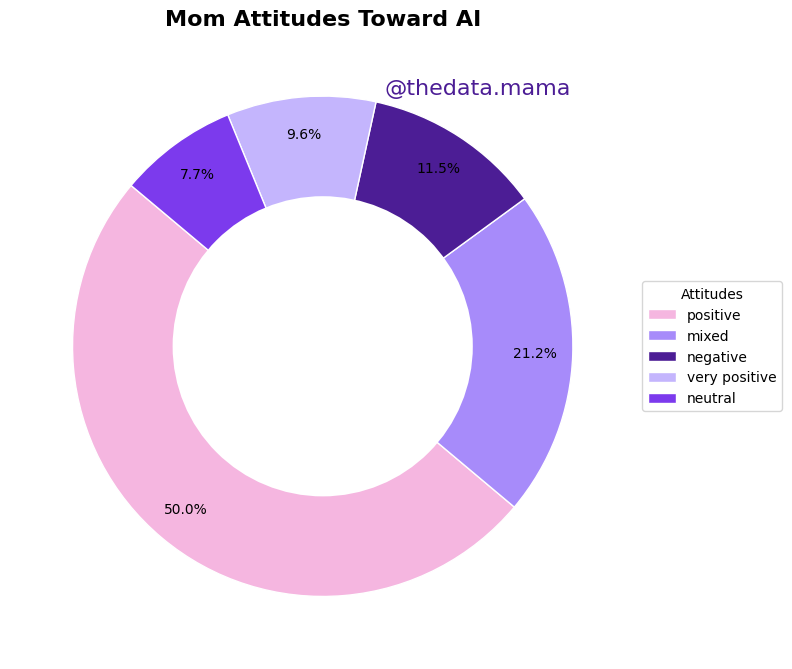

In [55]:
# Visualize the distribution of attitudes toward AI using a donut-style pie chart

attitude_color_map = {
    "very positive": "#C4B5FD",
    "positive": "#F5B6E0",
    "neutral": "#7C3AED",
    "mixed": "#A78BFA",
    "negative": "#4C1D95"
}
# Build color list in the order of your attitude_counts index
pie_colors = [attitude_color_map[a] for a in attitude_counts.index]

plt.figure(figsize=(8, 8))

# Outer ring (actual donut)
wedges, texts, autotexts = plt.pie(
    attitude_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    pctdistance=0.85,   # move percent labels inward
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Draw the donut hole
centre_circle = plt.Circle((0,0), 0.60, fc="#FFFFFF")  # hole color
plt.gca().add_artist(centre_circle)

# Title
plt.title("Mom Attitudes Toward AI", fontsize=16, fontweight='bold')

# Legend on the right
plt.legend(
    wedges,
    attitude_counts.index,
    title="Attitudes",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Brand tag (G)
plt.text(
    0.99,.99,
    "@thedata.mama",
    ha="right",
    va="bottom",
    fontsize=16,
    color="#4C1D95"
)

plt.tight_layout()
plt.show()


Now that we understand overall attitudes toward AI, the next step is to examine how moms actually use (or avoid) AI in practice. To do this, I convert open-ended responses into structured categories and define personas that capture distinct behavior patterns.

In [56]:
# Convert the list-based use_case_category feature into one column per category using multi-label binarization
# This creates numeric indicators for each AI use-case that can be used in clustering

mlb = MultiLabelBinarizer()

use_case_dummies = pd.DataFrame(
    mlb.fit_transform(df["use_case_category"]),   # <-- Series, not [["col"]]
    columns=mlb.classes_,
    index=df.index
)

df_ml = pd.concat([df, use_case_dummies], axis=1)
df_ml.columns

Index(['name', 'mom_type', 'uses_ai', 'how_use_ai', 'tools_mentioned',
       'attitude', 'use_case_category', 'mom_type_category', 'Avoids',
       'Business & Professional Support', 'Creative & Home Styling Support',
       'Doesn’t Trust AI With Parenting', 'Education & Homework Help',
       'Emotional Support & Reflection', 'Ethical/Environmental Concerns',
       'Event Planning & Life Organization',
       'Financial Planning & Credit Support', 'Hasn't Tried',
       'Health & Postpartum Support', 'Meal Planning, Routines & Mental Load',
       'No AI Use', 'Overwhelmed / Low Tech Confidence',
       'Parenting Support & Child Development',
       'Productivity, Writing & Organization', 'Travel & Outing Planning',
       'Trust Concerns'],
      dtype='str')

Next, I build a feature matrix from structured signals (AI usage, attitudes, mom type category, and multi-label use-case indicators). I then apply K-Means clustering to see whether data-driven groupings align with the persona definitions.

In [57]:
# Select features for clustering
features = [
    "uses_ai",              
    "attitude",             # we’ll one-hot encode this
    "mom_type_category"     # and this
 ] + list(mlb.classes_)     # all multi-label categories

# One-hot encode attitude + mom_type_category
df_encoded = pd.get_dummies(
    df_ml[["attitude", "mom_type_category"]],
    drop_first=False
)

# Combine everything
X = pd.concat(
    [df_ml["uses_ai"], df_encoded, df_ml[mlb.classes_]],
    axis=1
)


<h2>5. Model Preparation & Clustering </h2>

-------------------------
All engineered features were combined into a modeling matrix.
K-Means clustering was used to uncover natural groupings within the data. Three clusters were selected for their balance of interpretability and distinction.

The model assigned each mom to a cluster, forming the foundation for AI user personas.

KMeans works by measuring the distance between points. If features are on different scales, the feature with a larger magnitude will inflate the distance calculation, even if it isn't more important. Scaling prevents this by setting the mean to 0 and standard deviation of 1.

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # returns a numpy array

# Use X_scaled everywhere KMeans appears after this
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

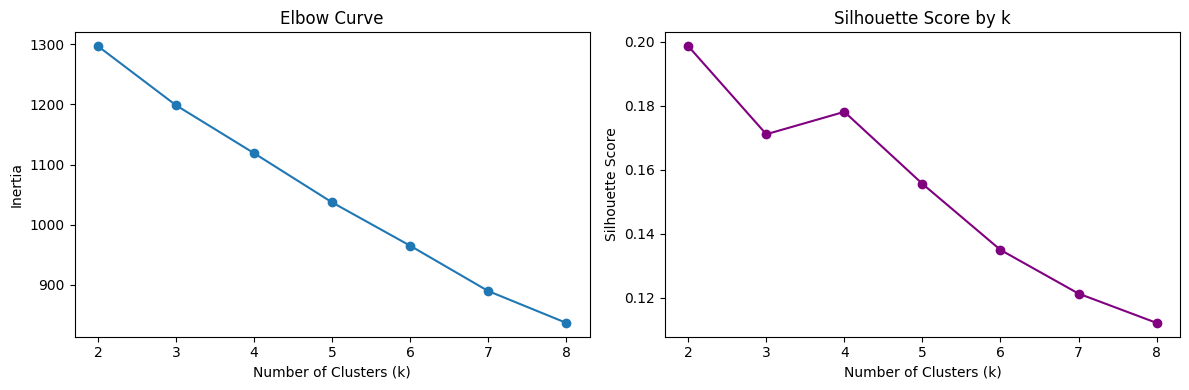

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)  
    
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, marker='o')
ax1.set_title('Elbow Curve')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, silhouette_scores, marker='o', color='purple')
ax2.set_title('Silhouette Score by k')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

K=3 is selected because inertia drops sharply from k=2 to k=3 and then flattens out. Beyond k=3, each additional cluster yields diminishing returns in inertia reduction, suggesting the added complexity isn't justified by the data.

Silhouette scores remain below 0.20 across all tested values of k, suggesting the clusters are not highly distinctive — which is expected with qualitative survey data. This supports using rule-based persona assignment as the primary framework rather than relying solely on KMeans. When clusters aren't well-separated, human-defined logic produces more interpretable and stable groupings."

In [60]:
df_ml["persona_cluster"] = kmeans.fit_predict(X_scaled)
df_ml[["name", "persona_cluster"]].head()




,name,persona_cluster
0,Alicia M.,2
1,Jenn G.,0
2,Valerie A.,2
3,Rhiannon S.,1
4,Shellby S.,2


In [61]:
persona_summary = df_ml.groupby("persona_cluster").agg({
    "mom_type_category": lambda x: x.mode()[0],
    "attitude": lambda x: x.mode()[0],
    "uses_ai": lambda x: x.mode()[0],
    **{cat: "mean" for cat in mlb.classes_}
}).reset_index()


In [64]:
# Inspect the top categories within each cluster to help interpret the persona characteristics
df_ml.groupby("persona_cluster").agg({
    "mom_type_category": lambda x: x.value_counts().index[0],
    "use_case_category": lambda x: x.value_counts().index[0],
    "attitude": lambda x: x.value_counts().index[0]
})


,mom_type_category,use_case_category,attitude
persona_cluster,,,
0,SAHM,"[Trust Concerns, Avoids]",negative
1,Working Mom,[Education & Homework Help],mixed
2,Working Mom,"[Productivity, Writing & Organization]",positive


<h2>6. Persona Interpretation</h2>

-------------------------
Each cluster represents a different pattern of AI engagement.
By comparing use cases, comfort levels, and personal context across clusters, we can describe personas such as:

- Moms who heavily use AI for planning and organization
- Moms who use AI selectively for creativity or schoolwork
- Moms who are cautious, limited, or avoidant users
- Moms who rarely engage due to low familiarity or interest

These personas help summarize the diverse ways mothers approach AI.

In [65]:
# Persona core category sets
ROUTINE_QUEEN_SET = {
    "Meal Planning, Routines & Mental Load",
    "Productivity, Writing & Organization",
    "Event Planning & Life Organization",
    "Travel & Outing Planning",
    "Health & Postpartum Support",
}

ORG_CHAOS_SET = {
    "Parenting Support & Child Development",
    "Meal Planning, Routines & Mental Load",
    "Emotional Support & Reflection",
    "Overwhelmed / Low Tech Confidence",
    "Health & Postpartum Support",
}

CEO_SET = {
    "Business & Professional Support",
    "Financial Planning & Credit Support",
    "Productivity, Writing & Organization",
    "Multi-Domain Power User",
}

CONSCIOUS_SET = {
    "Creative & Home Styling Support",
    "Trust Concerns",
    "Ethical/Environmental Concerns",
    "Avoids",
    "Doesn’t Trust AI With Parenting",
}

STUDY_SET = {
    "Education & Homework Help",
    "Productivity, Writing & Organization",
    "Emotional Support & Reflection",
    "Health & Postpartum Support",
}

AVOID_SET = {
    "Trust Concerns"
    "Ethical/Environmental Concerns"
    "Doesn’t Trust AI With Parenting"
    "No AI Use",
}

CURIOUS_SET = {
    "Trust Concerns",
    "Ethical/Environmental Concerns",
    "Doesn’t Trust AI With Parenting",
    "No AI Use",
    "Overwhelmed / Low Tech Confidence",
    "Hasn't Tried",
}


In [66]:
# Map each row's mom type, attitude, AI usage, and use cases into a human-readable persona label
def assign_persona(categories):
    """
    Assign a persona based on use-case categories.
    Returns one of:
      - 'The Routine Queen'
      - 'The Organized Chaos Mama'
      - 'The CEO Mom'
      - 'The Conscious Mama'
      - 'The Study-and-Survive Mom'
      - 'Unclear Persona'
    """

    if not categories:
        return "Unclear Persona"

    cats = set(categories)

    # If it's literally just Other, still unclear
    if cats == {"Other"}:
        return "Unclear Persona"

    # ---------- Strong override rules ----------

    # 1) Study-and-Survive: any education use is a strong signal
    if "Education & Homework Help" in cats:
        return "The Study-and-Survive Mom"

    # 2) Conscious Creator: strong concern + creative/values signals
    concern_cats = {
        "Trust Concerns",
        "Ethical/Environmental Concerns",
        "Avoids",
        "Doesn’t Trust AI With Parenting",
        "No AI Use"
    }

    # 3) CEO Mom: strong multi-domain / business signal
    if "Multi-Domain Power User" in cats:
        return "The CEO Mom"
        
    if len(cats) > 0 and cats.issubset(concern_cats):
        return "AI isn't for me"

    # ✅ RULE 2: Conscious Mama only if concerns + other behavior
    if cats and len(cats & concern_cats) >= 1 and "Overwhelmed / Low Tech Confidence" not in cats :
        return "The Conscious Creator"
        
    if "Overwhelmed / Low Tech Confidence" in cats and len(cats) == 1:
        return "AI-Curious Mama"
        
    if "Overwhelmed / Low Tech Confidence"  in cats and cats in concern_cats:
        return "AI-Curious Mama"

    # ---------- Score-based logic ----------

    scores = {
        "The Routine Queen": len(cats & ROUTINE_QUEEN_SET),
        "The Organized Chaos Mama": len(cats & ORG_CHAOS_SET),
        "The CEO Mom": len(cats & CEO_SET),
        "The Conscious Creator": len(cats & CONSCIOUS_SET),
        "The Study-and-Survive Mom": len(cats & STUDY_SET),
        "AI is not for me": len(cats & AVOID_SET),
        "AI curious but stuck": len(cats & CURIOUS_SET)
    }

    best_persona, best_score = max(scores.items(), key=lambda x: x[1])

    # if they match *at all*, give them that persona
    if best_score >= 1:
        return best_persona

    return "Unclear Persona"


In [67]:
# Apply the persona assignment function and review how many moms fall into each persona group
df_ml["persona"] = df_ml["use_case_category"].apply(assign_persona)
df_ml["persona"].value_counts()
df_ml.to_csv("persona_output.csv")

In [68]:
# Build a summary table describing each persona: size, top mom type, most common use case, and typical attitude
persona_summary = df_ml.groupby("persona").agg(
    n_moms=("name", "count"),
    top_mom_type=("mom_type_category", lambda x: x.value_counts().index[0]),
    top_use_case=("use_case_category", lambda x: x.value_counts().index[0]),
    top_attitude=("attitude", lambda x: x.value_counts().index[0]),
).reset_index()
persona_summary

,persona,n_moms,top_mom_type,top_use_case,top_attitude
0,AI curious but stuck,1,Working Mom,"[Overwhelmed / Low Tech Confidence, Hasn't Tried]",neutral
1,AI isn't for me,6,SAHM,"[Trust Concerns, Avoids]",negative
2,AI-Curious Mama,2,SAHM,[Overwhelmed / Low Tech Confidence],negative
3,The CEO Mom,8,Working Mom,[Business & Professional Support],positive
4,The Conscious Creator,3,General Mom,"[Meal Planning, Routines & Mental Load, Trust ...",mixed
5,The Organized Chaos Mama,6,SAHM,"[Meal Planning, Routines & Mental Load, Parent...",positive
6,The Routine Queen,17,Working Mom,"[Productivity, Writing & Organization]",positive
7,The Study-and-Survive Mom,9,Working Mom,[Education & Homework Help],mixed


In [69]:
# Build the final feature matrix for clustering from AI usage, attitudes, mom type, and use-case indicators
# One-hot encode attitude + mom_type_category
cat_encoded = pd.get_dummies(
    df_ml[["attitude", "mom_type_category"]],
    drop_first=False
)

# Multi-label use case dummies (from mlb)
use_case_encoded = df_ml[mlb.classes_]

# Combine into feature matrix X
X = pd.concat([df["uses_ai"], cat_encoded, use_case_encoded], axis=1)
X.head()


,uses_ai,attitude_mixed,attitude_negative,attitude_neutral,attitude_positive,attitude_very positive,mom_type_category_General Mom,mom_type_category_Other Mom,mom_type_category_SAHM,mom_type_category_Student Mom,...,Financial Planning & Credit Support,Hasn't Tried,Health & Postpartum Support,"Meal Planning, Routines & Mental Load",No AI Use,Overwhelmed / Low Tech Confidence,Parenting Support & Child Development,"Productivity, Writing & Organization",Travel & Outing Planning,Trust Concerns
0,1,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,1,0,0
1,0,False,True,False,False,False,False,False,True,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,True,False,False,False,False,False,...,0,0,1,0,0,0,0,0,0,0
3,1,True,False,False,False,False,False,False,False,False,...,0,0,0,1,0,0,0,0,0,1
4,1,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,1,0,0


To validate interpretability, I compare persona labels (rule-based/human-readable) against the unsupervised cluster assignments. Strong alignment suggests the personas capture real structure in the data; misalignment can indicate overlap between personas or areas to refine definitions.

In [71]:
# Compare human-defined personas with model-assigned clusters using a crosstab
ct = pd.crosstab(df_ml["persona"], df_ml["persona_cluster"])
ct

cluster,0,1,2
persona,,,
AI curious but stuck,1,0,0
AI isn't for me,6,0,0
AI-Curious Mama,2,0,0
The CEO Mom,0,5,3
The Conscious Creator,0,0,3
The Organized Chaos Mama,1,3,2
The Routine Queen,0,16,1
The Study-and-Survive Mom,0,3,6


In [72]:
# View the same crosstab as row-wise proportions to see cluster alignment within each persona
ct_prop = pd.crosstab(df_ml["persona"], df_ml["persona_cluster"], normalize="index")
ct_prop

cluster,0,1,2
persona,,,
AI curious but stuck,1.000000,0.000000,0.000000
AI isn't for me,1.000000,0.000000,0.000000
AI-Curious Mama,1.000000,0.000000,0.000000
The CEO Mom,0.000000,0.625000,0.375000
The Conscious Creator,0.000000,0.000000,1.000000
The Organized Chaos Mama,0.166667,0.500000,0.333333
The Routine Queen,0.000000,0.941176,0.058824
The Study-and-Survive Mom,0.000000,0.333333,0.666667


In [73]:
# Build a table showing the percentage of moms in each persona who use each AI category
use_case_cols = list(mlb.classes_)

# make sure these columns exist in df_ml
use_case_cols = [c for c in use_case_cols if c in df_ml.columns]

# Group by persona and take the mean (fraction of moms in that persona using each category)
persona_use_matrix = df_ml.groupby("persona")[use_case_cols].mean()

# Turn into percentages
persona_use_matrix = persona_use_matrix * 100

persona_use_matrix.round(1)


,Avoids,Business & Professional Support,Creative & Home Styling Support,Doesn’t Trust AI With Parenting,Education & Homework Help,Emotional Support & Reflection,Ethical/Environmental Concerns,Event Planning & Life Organization,Financial Planning & Credit Support,Hasn't Tried,Health & Postpartum Support,"Meal Planning, Routines & Mental Load",No AI Use,Overwhelmed / Low Tech Confidence,Parenting Support & Child Development,"Productivity, Writing & Organization",Travel & Outing Planning,Trust Concerns
persona,,,,,,,,,,,,,,,,,,
AI curious but stuck,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
AI isn't for me,66.7,0.0,0.0,16.7,0.0,0.0,16.7,0.0,0.0,0.0,0.0,0.0,16.7,0.0,0.0,0.0,0.0,33.3
AI-Curious Mama,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
The CEO Mom,0.0,75.0,12.5,0.0,0.0,12.5,0.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,37.5,0.0,0.0
The Conscious Creator,0.0,33.3,0.0,0.0,0.0,0.0,33.3,0.0,0.0,0.0,0.0,33.3,33.3,0.0,0.0,0.0,33.3,66.7
The Organized Chaos Mama,16.7,16.7,0.0,0.0,0.0,33.3,0.0,0.0,0.0,0.0,0.0,33.3,0.0,16.7,50.0,0.0,0.0,0.0
The Routine Queen,0.0,0.0,11.8,0.0,0.0,5.9,0.0,23.5,17.6,0.0,23.5,52.9,0.0,0.0,17.6,58.8,5.9,0.0
The Study-and-Survive Mom,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,11.1,0.0,11.1,22.2,0.0,0.0,0.0,22.2,0.0,11.1


Below are key behavioral patterns by persona using the percentage table/heatmap. Each row shows what a persona most commonly uses AI for (and what they avoid), making differences between groups immediately visible.

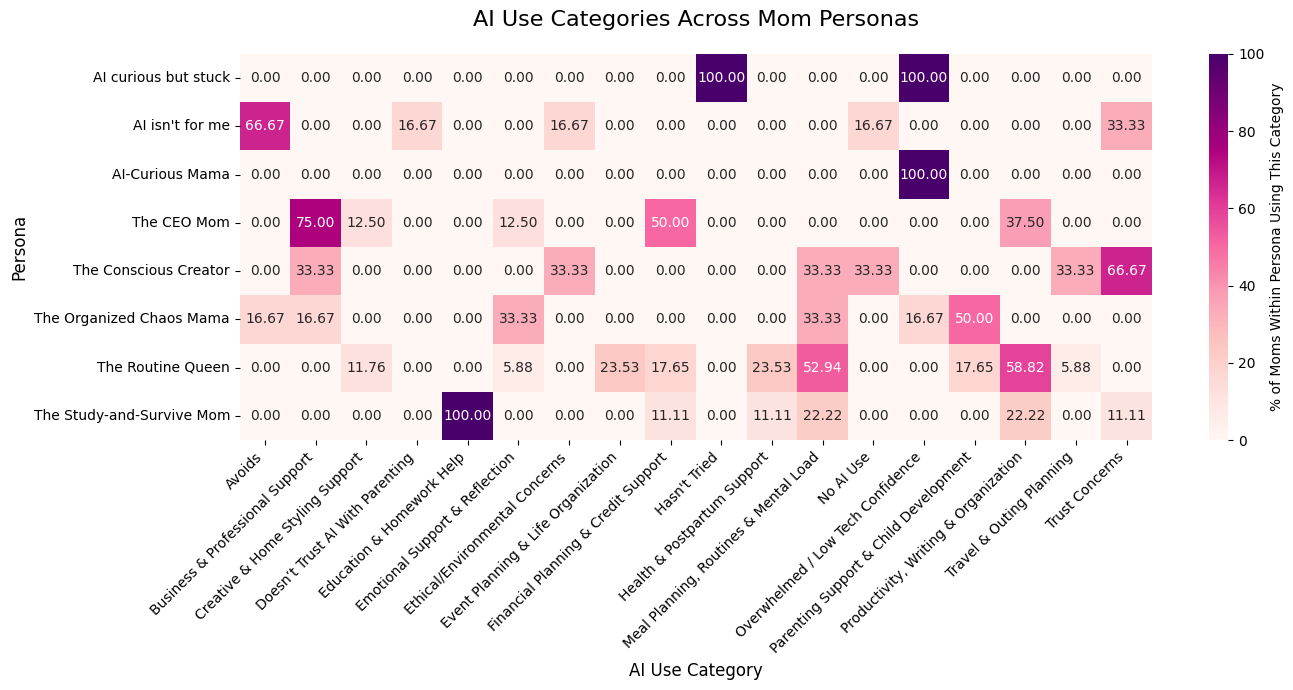

In [87]:
# Visualize AI use-case patterns across personas using a heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    persona_use_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdPu",
    cbar_kws={"label": "% of Moms Within Persona Using This Category"}
)

plt.title("AI Use Categories Across Mom Personas", fontsize=16, pad=20)
plt.xlabel("AI Use Category", fontsize=12)
plt.ylabel("Persona", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [75]:
# Copy the persona-use matrix to prepare it for radar chart plotting
radar_df = persona_use_matrix.copy()  # replace with your actual table variable

radar_df

,Avoids,Business & Professional Support,Creative & Home Styling Support,Doesn’t Trust AI With Parenting,Education & Homework Help,Emotional Support & Reflection,Ethical/Environmental Concerns,Event Planning & Life Organization,Financial Planning & Credit Support,Hasn't Tried,Health & Postpartum Support,"Meal Planning, Routines & Mental Load",No AI Use,Overwhelmed / Low Tech Confidence,Parenting Support & Child Development,"Productivity, Writing & Organization",Travel & Outing Planning,Trust Concerns
persona,,,,,,,,,,,,,,,,,,
AI curious but stuck,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,100.0,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
AI isn't for me,66.666667,0.000000,0.000000,16.666667,0.0,0.000000,16.666667,0.000000,0.000000,0.0,0.000000,0.000000,16.666667,0.000000,0.000000,0.000000,0.000000,33.333333
AI-Curious Mama,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
The CEO Mom,0.000000,75.000000,12.500000,0.000000,0.0,12.500000,0.000000,0.000000,50.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,37.500000,0.000000,0.000000
The Conscious Creator,0.000000,33.333333,0.000000,0.000000,0.0,0.000000,33.333333,0.000000,0.000000,0.0,0.000000,33.333333,33.333333,0.000000,0.000000,0.000000,33.333333,66.666667
The Organized Chaos Mama,16.666667,16.666667,0.000000,0.000000,0.0,33.333333,0.000000,0.000000,0.000000,0.0,0.000000,33.333333,0.000000,16.666667,50.000000,0.000000,0.000000,0.000000
The Routine Queen,0.000000,0.000000,11.764706,0.000000,0.0,5.882353,0.000000,23.529412,17.647059,0.0,23.529412,52.941176,0.000000,0.000000,17.647059,58.823529,5.882353,0.000000
The Study-and-Survive Mom,0.000000,0.000000,0.000000,0.000000,100.0,0.000000,0.000000,0.000000,11.111111,0.0,11.111111,22.222222,0.000000,0.000000,0.000000,22.222222,0.000000,11.111111


In [76]:
# Replace any missing values with 0 to avoid issues in the radar plot
radar_df = radar_df.fillna(0)

In [77]:
#This will be used later on for the long labels
import textwrap

def wrap_labels(labels, width=18):
    return ['\n'.join(textwrap.wrap(l, width)) for l in labels]


# Define a helper function to plot AI use patterns for each persona as a radar chart
def plot_persona_radar(df, title="Persona AI Usage Radar"):
    categories = df.columns.tolist()
    N = len(categories)

    # Angle for each axis
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    # Create figure
    plt.figure(figsize=(10, 10))
    plt.subplot(111, polar=True)
    plt.title(title, size=16, y=1.1)

    # Brand-aligned colors
    colors = [
        "#00aba9",  # purple
        "#ff0097",  # pink
        "#a200ff",  # deep purple
        "#1ba1e2",  # lilac
        "#f09609"   # soft pink
    ]

    for i, (persona, row) in enumerate(df.iterrows()):
        values = row.tolist()
        values += values[:1]

        plt.plot(
            angles,
            values,
            linewidth=2,
            linestyle='solid',
            label=persona,
            color=colors[i % len(colors)]
        )
        plt.fill(
            angles,
            values,
            alpha=0.15,
            color=colors[i % len(colors)]
        )

    # Fix axis labels
    plt.xticks(angles[:-1], wrap_labels(categories), fontsize=10)
    plt.yticks(fontsize=8)
    plt.tick_params(axis='x', pad=30)


    plt.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1))
    plt.show()
    


Training and testing on the same data would cause overfitting — the model memorizes the training data instead of learning patterns that generalize to new, unseen data.

The features come from three sources:
- Encoded demographic and attitude features (uses_ai, attitude, mom_type)
- Use case categories generated from the multi-label keyword classifier
- TF-IDF scores derived from raw open-text responses

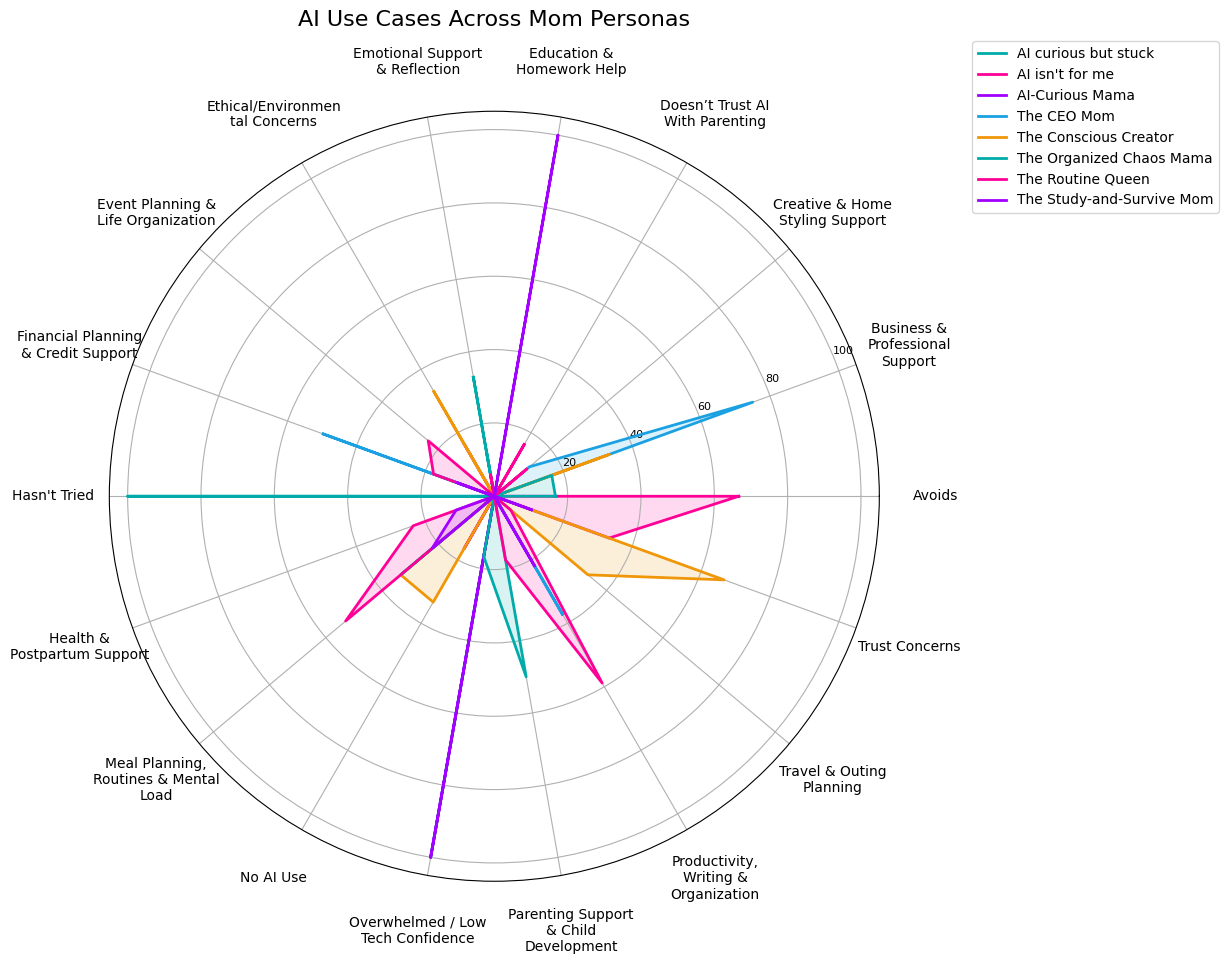

In [78]:
# Plot the radar chart to compare AI use across personas at a glance
plot_persona_radar(radar_df, title="AI Use Cases Across Mom Personas")

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

# Combine all features
X_combined = sp.hstack([tfidf_matrix, X_scaled])

# Target
y = df_ml["persona"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=.2, random_state=42 )# random_state=42 ensures consistency so that we get repeatable results. 

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [84]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

     AI curious but stuck       0.00      0.00      0.00         1
          AI isn't for me       0.25      1.00      0.40         1
          AI-Curious Mama       0.00      0.00      0.00         2
              The CEO Mom       0.00      0.00      0.00         0
    The Conscious Creator       1.00      1.00      1.00         1
 The Organized Chaos Mama       0.00      0.00      0.00         2
        The Routine Queen       0.75      1.00      0.86         3
The Study-and-Survive Mom       1.00      1.00      1.00         1

                 accuracy                           0.55        11
                macro avg       0.38      0.50      0.41        11
             weighted avg       0.41      0.55      0.45        11



/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

Accuracy in this dataset was 55%. Considering the sample size was only 52 rows, this provides meaningful results — outperforming random chance by 42.5% (baseline: 12.5% for 8 classes).

The Routine Queen was the model's strongest persona — 75% of its predictions were correct and it successfully identified all true Routine Queens in the test set.

The AI-Curious Mama scored the worst due to class imbalance — with only 2 examples in the test set, the model had insufficient signal to learn the pattern.

With a larger dataset, I would collect more examples of underrepresented personas like AI-Curious Mamas and The Organized Chaos Mamas to address class imbalance. This would give the model sufficient signal to learn behavioral patterns, likely improving accuracy beyond 55%

## 🔑 Key Findings

- 80% of moms surveyed use AI for a variety of purposes.
- The most common AI use case was Education & Homework Help, 
  including homework support, lesson planning, and breaking down 
  complex concepts for their children.
- Non-adopters are often overwhelmed by AI or have low confidence 
  in AI tools, suggesting that onboarding resources and simplified 
  entry points could drive adoption.
- The Routine Queen was the most common persona, suggesting that 
  moms are primarily drawn to AI as a tool for reducing mental load 
  and managing daily structure.